# CReM tutorial

This tutorial will demonstrate some basic operations how to enumerate molecules based on a reference (parent) compound. There are three main functions which GROW, MUTATE or LINK molecules. We will look on them and some of their arguments. For full reference please visit documentation pages https://crem.readthedocs.io/en/latest/index.html

In [1]:
import random

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem.Draw import IPythonConsole
from IPython.display import SVG, Image
IPythonConsole.molSize = (400,300)
IPythonConsole.ipython_useSVG=True

from crem.crem import mutate_mol, grow_mol, link_mols, make_cycle

In [2]:
def drawgrid(mols, highlight=0):
    """
    highlight: 0 - no highlight
               1 - highlight changed atoms
               2 - highlight unchanged atoms
    """
    if highlight == 0:
        return Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,200), useSVG=True)
    else:
        ids_list = []
        for m in mols:
            ids = []
            for a in m.GetAtoms():
                if '__crem' in a.GetPropsAsDict() and a.GetBoolProp('__crem'):
                    ids.append(a.GetIdx())
            if highlight == 1:
                ids_list.append(ids)
            elif highlight == 2:
                ids_list.append(list(set(range(m.GetNumAtoms())) - set(ids)))
        return Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,200), 
                                    highlightAtomLists=ids_list, useSVG=True)

To work with CReM you need a database of interchangeable fragments. This database can be prepared from the custom dataset of molecules. Alternatively you can use databases available at http://www.qsar4u.com/pages/crem.php which were prepared from ChMEBL compounds.

In [3]:
# you may download an extract ChEMBL36 fragment database - https://zenodo.org/records/20717965/files/chembl36_v1.db.gz?download=1
# specify the path to the fragment database
db_fname = 'chembl36_v1.db'

CReM database v1 have named sets of fragments passed via set_names argument to all functions, if omitted - replacements will be searched across all fragment sets.
If you use chembl36_v1.db, there are will be several fragment sets:
- chembl36 - all structures were fragmented
- chembl36_noalerts - fragmented structures did not contain any alerts from the list of BMS, Dundee, Glaxo, Inpharmatica and PAINS
- chembl36_noalerts_sa25 - fragmented structures did not contain alerts and had SA scores below 2.5
- chembl36_noalerts_sa2 - fragmented structures did not contain alerts and had SA scores below 2

In [4]:
set_name = 'chembl36_noalerts'

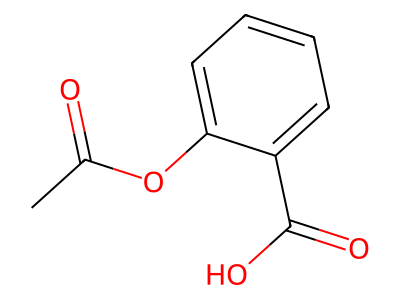

In [5]:
# take aspirin as an example parent molecule
mol = Chem.MolFromSmiles('O=C(C)Oc1ccccc1C(=O)O')
mol

## Grow

GROW is replacement of hydrogens with other fragments. Only one hydrogen is replaced at a time.

In [6]:
# let's grow the molecule
# we changed default values of one argument to receive RDKit Mol objects
mols = list(grow_mol(mol, db_fname, return_mol=True, set_names = set_name))
len(mols)

69

The function returns the list of smiles and mol objects. This might be not very convenient and we consider to change this behavior in future releases to return either smiles or molecules but not both.

In [7]:
mols[:4]

[['CCC(=O)Oc1ccccc1C(=O)O', <rdkit.Chem.rdchem.Mol at 0x785f39ad6ab0>],
 ['CCCC(=O)Oc1ccccc1C(=O)O', <rdkit.Chem.rdchem.Mol at 0x785f39ad69d0>],
 ['NCC(=O)Oc1ccccc1C(=O)O', <rdkit.Chem.rdchem.Mol at 0x785f39ad6960>],
 ['NCCC(=O)Oc1ccccc1C(=O)O', <rdkit.Chem.rdchem.Mol at 0x785f39ad6810>]]

We will keep only Mol objects for further manipulations

In [8]:
mols = [i[1] for i in mols]
mols[:4]

There are three modes to visualize generated molecules. 0 - no highlighting, 1 - highligth changed atoms, 2 - highlight unchanged atoms

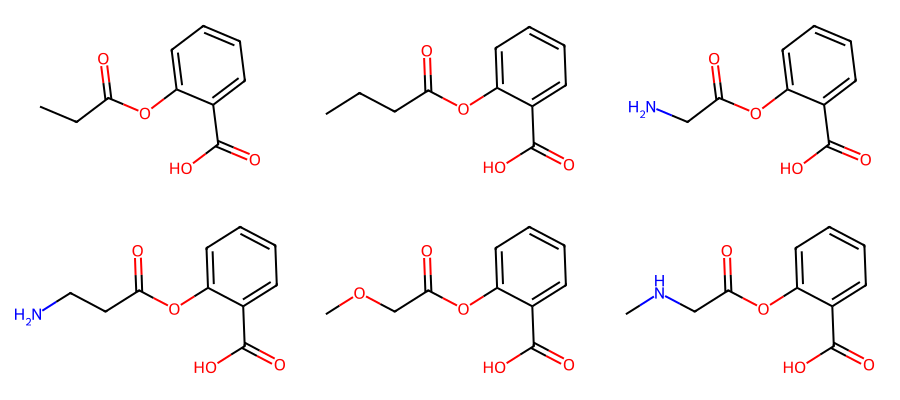

In [9]:
# depict molecules without highlighting
drawgrid(mols[:6], 0)

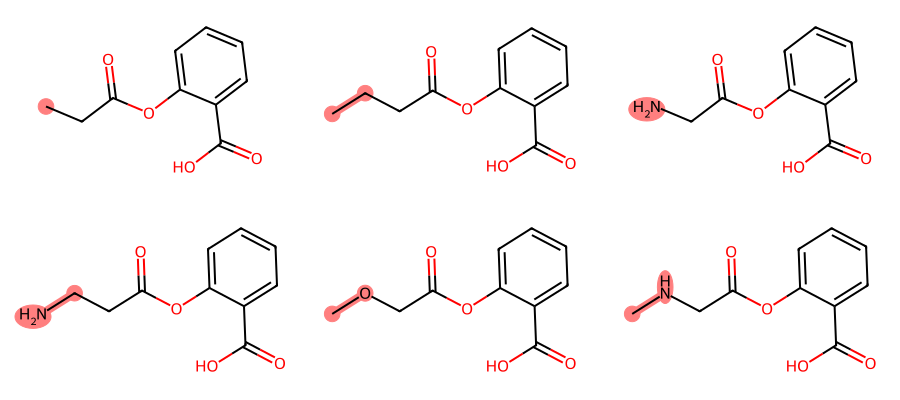

In [10]:
# depict molecules without highlighting of changed atoms
drawgrid(mols[:6], 1)

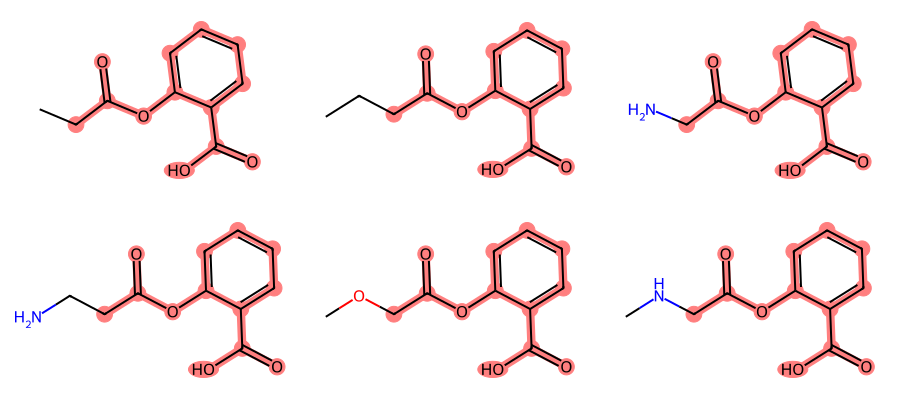

In [11]:
# depict molecules with highlighting of unchanged atoms
drawgrid(mols[:6], 2)

We used default arguments of the grow function. Therefore the structural changes are small, because by default the size of a replacing fragment is 1-2 heavy atoms.
Let's change the default parameters to replace hydrogens with larger fragments.

In [12]:
mols = list(grow_mol(mol, db_fname, return_mol=True, min_atoms=4, max_atoms=6, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

2275

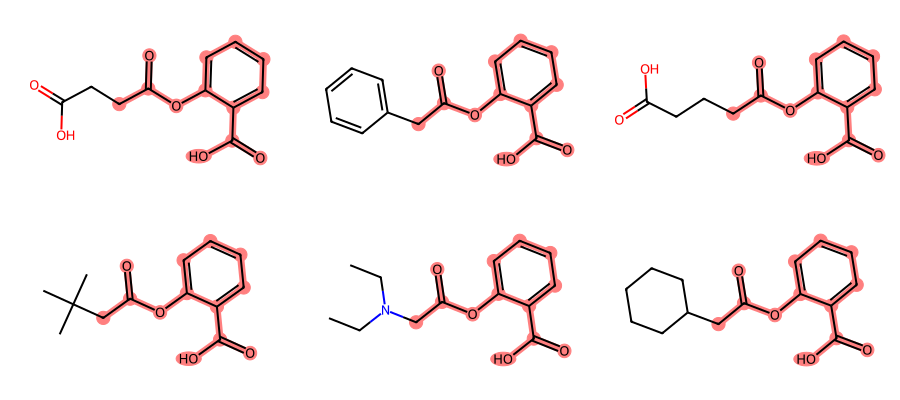

In [13]:
drawgrid(mols[:6], 2)

The user can also control the context radius which is considered for replacement. This is the important option because this determines how conservative replacements will be. The larger radius will produce more conservative replacements which will be less in number. Decreasing the radius may decrease synthetic feasibility and chemical rationality of generated structures. Therefore, for the whole tutorial we will use radius 3 (default) because at this radius the majority of functional groups are distinguishable.

In [14]:
# just for illustration change the radius to 1
mols = list(grow_mol(mol, db_fname, return_mol=True, radius=1, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

74

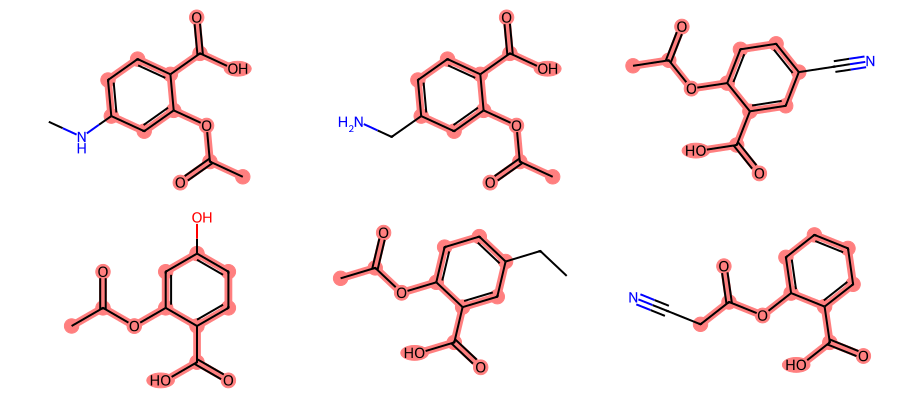

In [15]:
drawgrid(random.sample(mols, 6), 2)

The user can also control which atoms in a molecule can be changed. It is possible to specify either ids of atoms which should be protected from changes (e.g. scaffold, pharmacophores) or ids of atoms which should be replaced.
In the case if your parent molecule contains explicit hydrogens you can specify either ids of hydrogens or ids of heavy atoms whose hydrogen should be protected/replaced

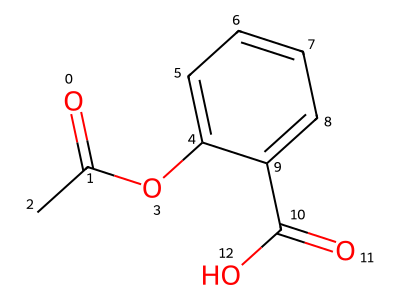

In [16]:
# let's depict atom ids of the aspirine molecule
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.drawOptions.addAtomIndices = True
mol

In [17]:
IPythonConsole.drawOptions.addAtomIndices = False

In [18]:
# let's generate molecules by growing only at atom 12 or 5
mols = list(grow_mol(mol, db_fname, return_mol=True, replace_ids=[5, 12], set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

16

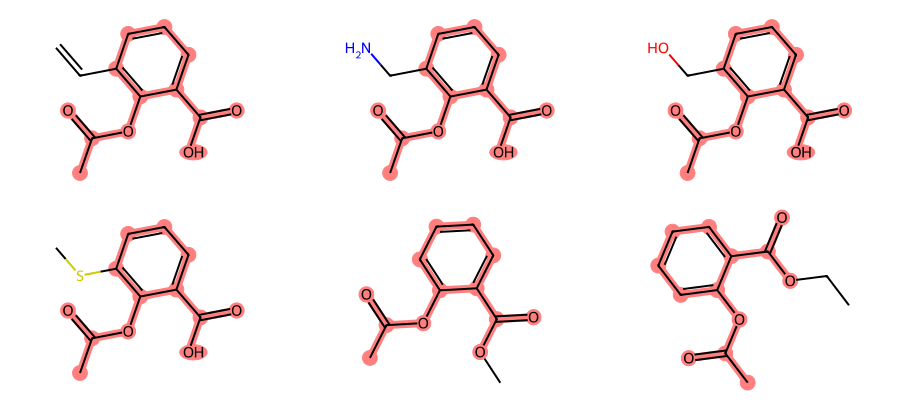

In [19]:
drawgrid(mols[10:], 2)

## Mutate

MUTATE is a more general operation that GROW. This replaces any fragments not only hydrogens. Thus, it can be used to replace hydrogens with heavy atom fragments (like GROW) or heavy atom fragments with hydrogens or heavy atom fragments with other heavy atom fragments. Below we will demonstrate how to control this.

In [20]:
# default mutation of aspirine
mols = list(mutate_mol(mol, db_fname, return_mol=True, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

4985

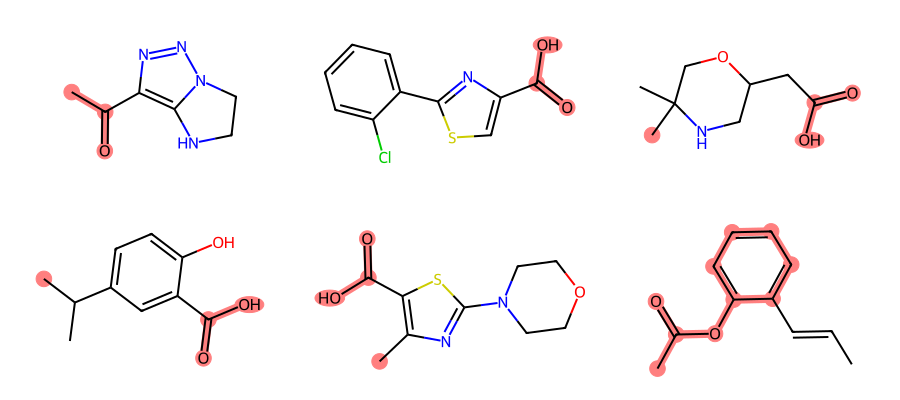

In [21]:
drawgrid(random.sample(mols, 6), 2)

You see large changes in the structure. This was happened due to default arguments. By default the size of replaced fragmnets is from 0 to 10 heavy atoms. 0 means hydrogens, but unless molecule have explicit hydrogens they will not be replaced.

In [22]:
# replace only fragments having 1 heavy atom.
mols = list(mutate_mol(mol, db_fname, return_mol=True, min_size=1, max_size=1, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

31

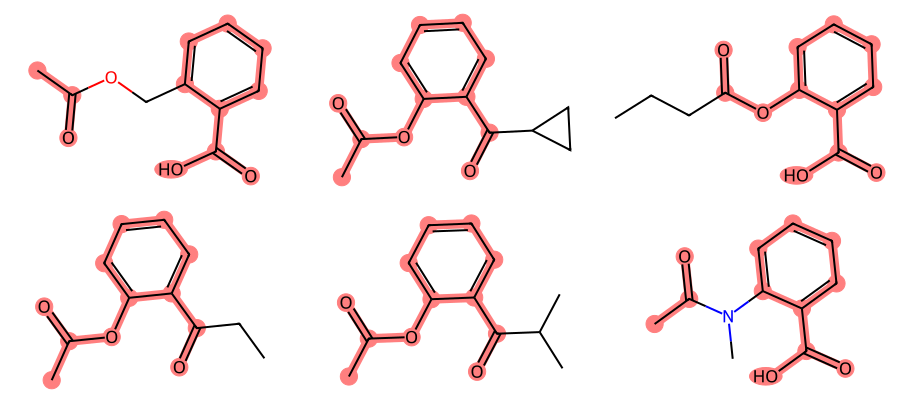

In [23]:
drawgrid(random.sample(mols, 6), 2)

The size of replacing fragments is determined relatively to the size of a replaced fragment. There are two arguments: min_inc(rement) and max_inc(rement). If the size of a replaced fragment is N, the the size of replacing fragments will be from N + min_inc to N + max_inc.

In [24]:
mols = list(mutate_mol(mol, db_fname, return_mol=True, min_size=1, max_size=2, min_inc=-1, max_inc=1, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

41

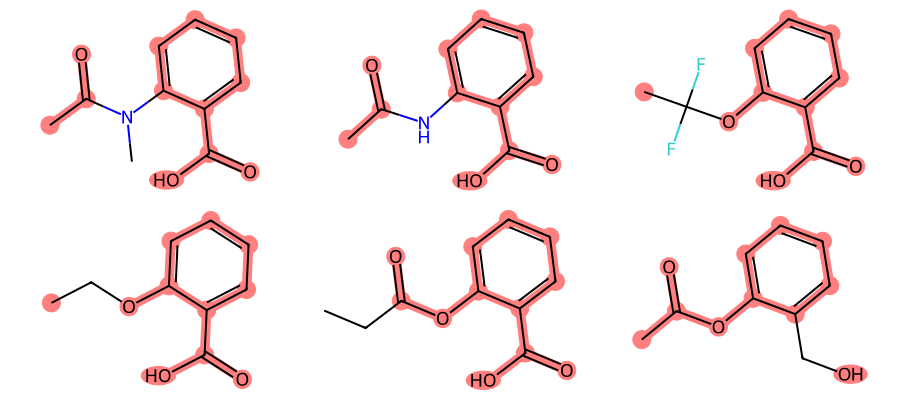

In [25]:
drawgrid(random.sample(mols, 6), 2)

Using negative increments you can remove particular fragments (replace them with hydrogens)

In [26]:
mols = list(mutate_mol(mol, db_fname, return_mol=True, min_size=1, max_size=1, min_inc=-1, max_inc=-1, set_names = 'chembl36'))
mols = [i[1] for i in mols]
len(mols)

2

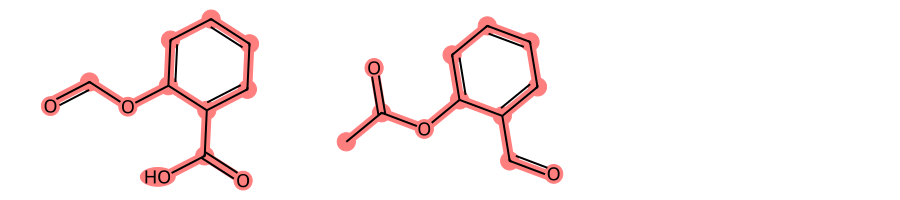

In [27]:
drawgrid(mols, 2)

Or you can replace fragments only with larger ones

In [28]:
mols = list(mutate_mol(mol, db_fname, return_mol=True, min_size=1, max_size=1, min_inc=1, max_inc=2, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

27

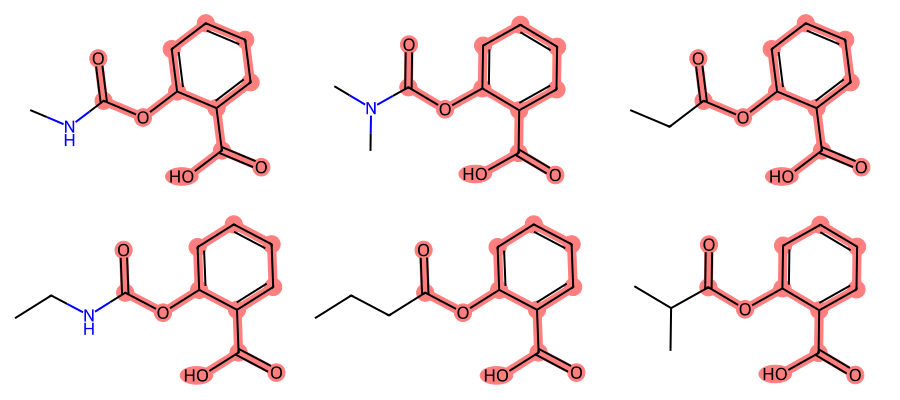

In [29]:
drawgrid(mols[:6], 2)

As it was mentioned above, if the user provide a molecules with explicit hydrogens these hydrogens can be replaced like in the grow function but min_size should be set to 0. The call below will result in identical output to the grow function. Actually grow is a convenience wrapper over the mutate function.

In [30]:
mols = list(mutate_mol(Chem.AddHs(mol), db_fname, return_mol=True, min_size=0, max_size=0, min_inc=1, max_inc=2, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

69

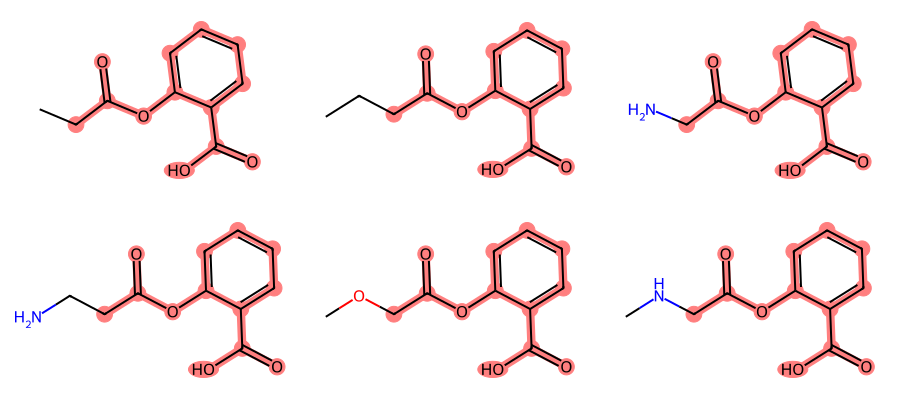

In [31]:
drawgrid(mols[:6], 2)

The user can protect particular atoms from changes or replace particular atoms.

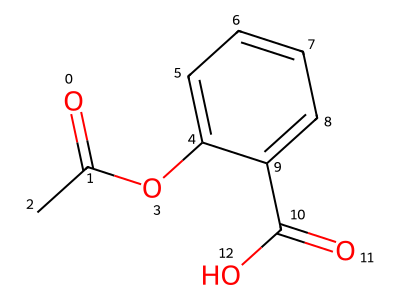

In [32]:
IPythonConsole.drawOptions.addAtomIndices = True
mol

In [33]:
IPythonConsole.drawOptions.addAtomIndices = False

In [34]:
# protect acetyl from changes (atom ids 0, 1 ,2, 3)
mols = list(mutate_mol(mol, db_fname, return_mol=True, protected_ids=[0, 1, 3], set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

292

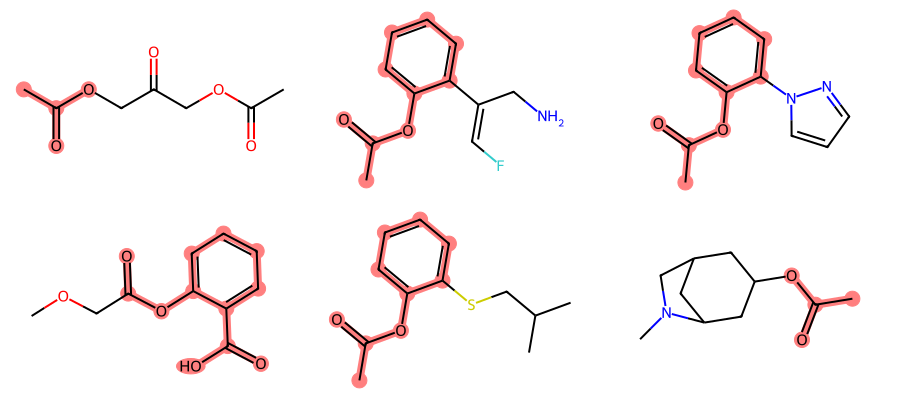

In [35]:
drawgrid(random.sample(mols, 6), 2)

In [36]:
# replace ester group C(=O)O with atom ids 0, 1 and 3
mols = list(mutate_mol(Chem.AddHs(mol), db_fname, return_mol=True, replace_ids=[0, 1, 3], set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

162

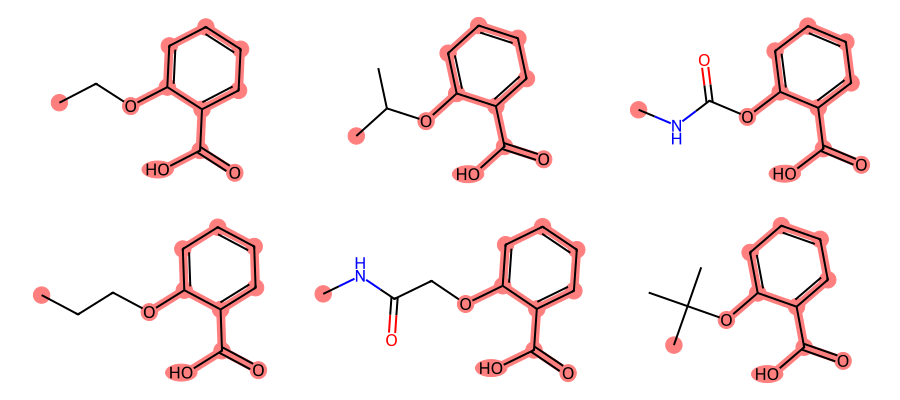

In [37]:
drawgrid(mols[:6], 2)

In [38]:
# if you will specify to replace fragments with at most 2 atoms then the whole ester group will not be replaced, but oxygen and carbonyl will be repalced
mols = list(mutate_mol(Chem.AddHs(mol), db_fname, return_mol=True, min_size=0, max_size=2, replace_ids=[0, 1, 3], set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

64

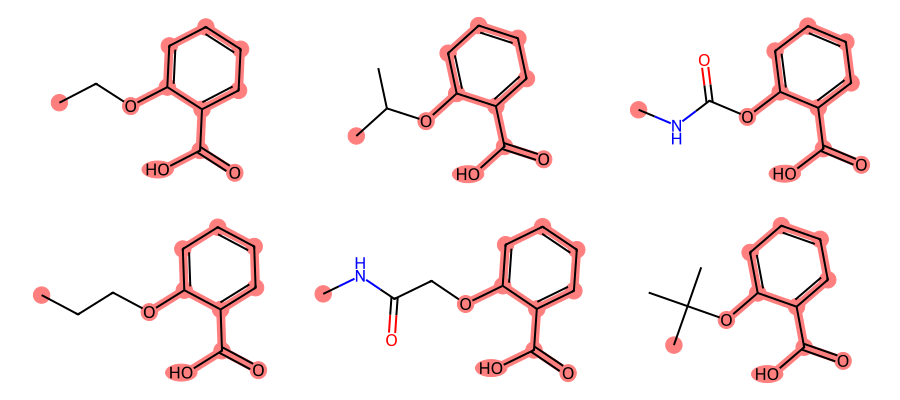

In [39]:
drawgrid(mols[:6], 2)

## Link

LINK replaces hydrogens at two molecules with the linker fragment from the database.

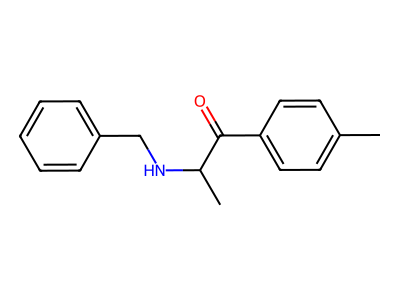

In [40]:
# benzedrone
mol2 = Chem.MolFromSmiles('c2ccccc2CNC(C)C(=O)c(cc1)ccc1C')
mol2

In [41]:
mols = list(link_mols(mol, mol2, db_fname, return_mol=True, set_names = set_name))
mols = [i[1] for i in mols]
len(mols)

297

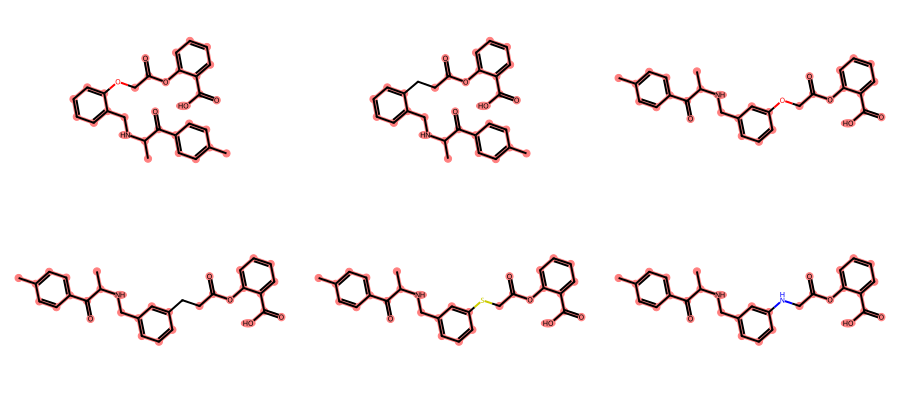

In [42]:
drawgrid(mols[:6], 2)

It is also possible to specify the size of a linker and particular atoms which should be protected or linked.

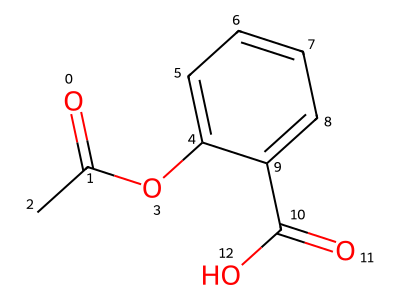

In [43]:
IPythonConsole.drawOptions.addAtomIndices = True
mol

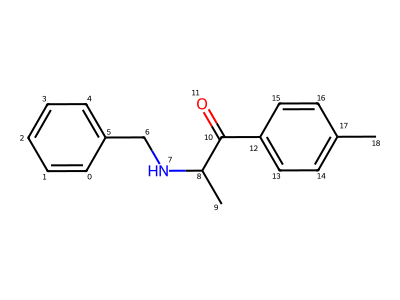

In [44]:
mol2

In [45]:
IPythonConsole.drawOptions.addAtomIndices = False

In [46]:
# let's link atom 12 of aspirin with atom 2 of benzedrone
mols = list(link_mols(mol, mol2, db_fname, return_mol=True, min_atoms=1, max_atoms=6, replace_ids_1=[12], replace_ids_2=[2], set_names='chembl36_noalerts'))
mols = [i[1] for i in mols]
len(mols)

68

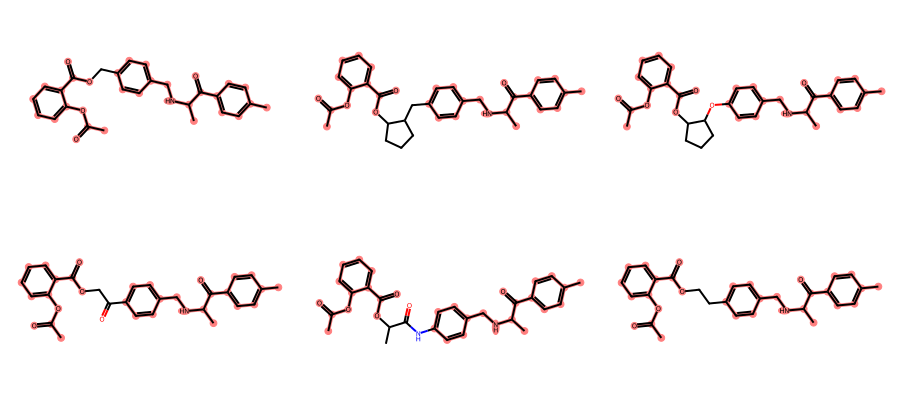

In [47]:
drawgrid(mols[:6], 2)

To control the distance between linked molecules the user can provide the value of the dist argument which is a number of bonds between connected molecules in a generate structure.

In [48]:
# link molecules by fragments which separate them by exactly two bonds
mols = list(link_mols(mol, mol2, db_fname, return_mol=True, min_atoms=1, max_atoms=6, dist=2, set_names='chembl36_noalerts'))
mols = [i[1] for i in mols]
len(mols)

508

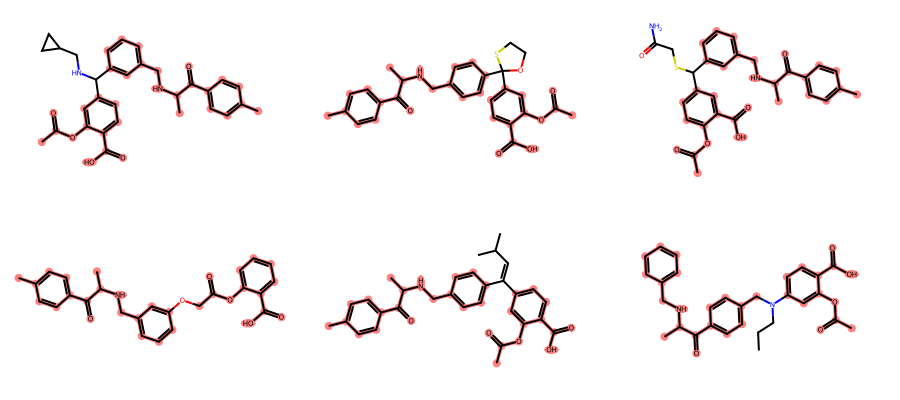

In [49]:
drawgrid(random.sample(mols, 6), 2)

In [50]:
# dist argument can be a tuple of lower and upper distance values
mols = list(link_mols(mol, mol2, db_fname, return_mol=True, min_atoms=1, max_atoms=6, dist=(2, 3), set_names='chembl36_noalerts'))
mols = [i[1] for i in mols]
len(mols)

1601

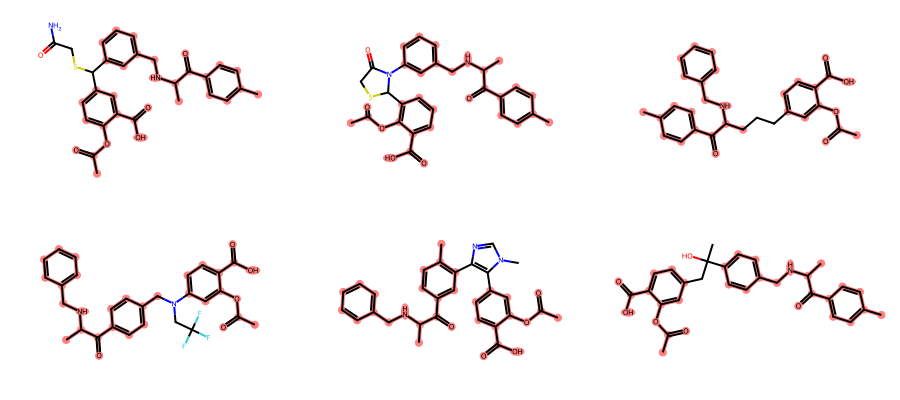

In [51]:
drawgrid(random.sample(mols, 6), 2)

## Make_cycle

CReM from v0.3 supports intramolecular ring closure. For that the fragmwent database should be generated with --frag-mode argument set to approriate value (default value both_optimal will generate acyclic fragments as well as ring closures)

In [52]:
mols = list(make_cycle(mol, db_fname, return_mol=True, set_names='chembl36_noalerts'))
mols = [i[1] for i in mols]
len(mols)

1474

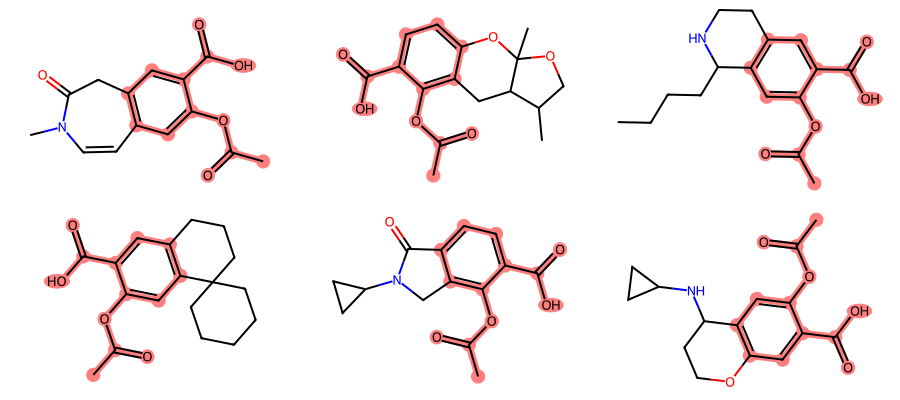

In [53]:
drawgrid(random.sample(mols, 6), 2)

By default ring closures are taken from real ring closures extracted from fragmented structures. To reach wider scope the user may switch to use additionally to natural ring closures ordinary linking fragments.

In [54]:
mols = list(make_cycle(mol, db_fname, return_mol=True, ring_closures=False, set_names='chembl36_noalerts'))
mols = [i[1] for i in mols]
len(mols)

5351

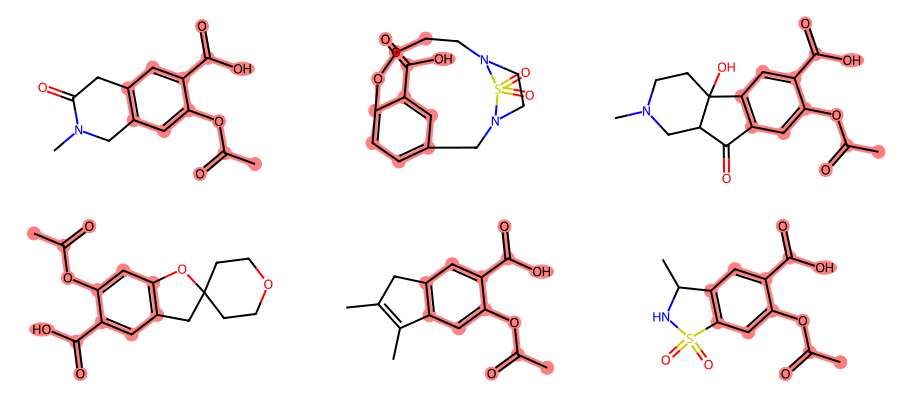

In [55]:
drawgrid(random.sample(mols, 6), 2)

In this mode some of generated structures can become physically implausible. Therefore, this mode should be used with care and it may be recommended mainly for macrocycle creation

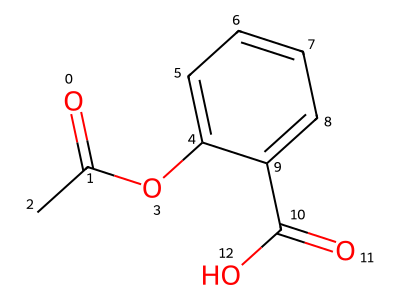

In [56]:
IPythonConsole.drawOptions.addAtomIndices = True
mol

In [57]:
IPythonConsole.drawOptions.addAtomIndices = False

Let's link atoms 2 and 12 in a macrocycle ring

In [58]:
mols = list(make_cycle(mol, db_fname, return_mol=True, ring_closures=False, replace_ids=(2, 12), set_names='chembl36_noalerts'))
mols = [i[1] for i in mols]
len(mols)

6

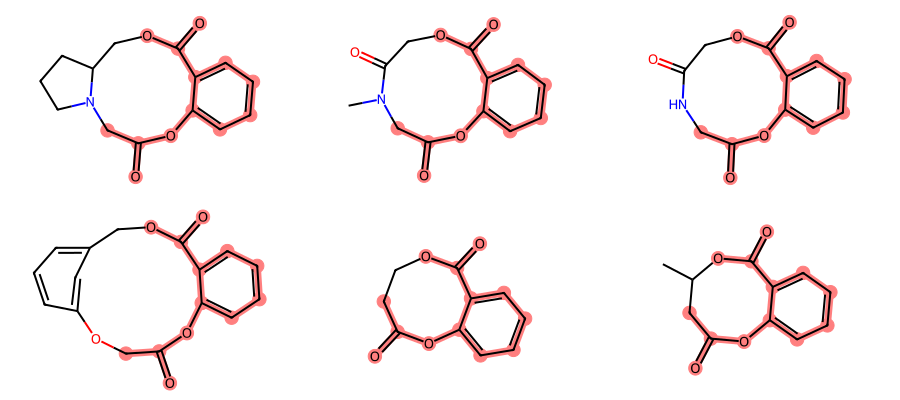

In [59]:
drawgrid(random.sample(mols, 6), 2)